In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\vishnupriya\OneDrive\Documents\Restaurant-Rating-Prediction\data\Dataset.csv")

# Display first 5 rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
# Dataset Information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

Dataset Shape: (9551, 21)

Column Names:
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-nu

In [7]:
# Check missing values
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Cuisines    9
dtype: int64


In [8]:
# Statistical Summary
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [9]:
# Fill missing values in Cuisines column
df['Cuisines'] = df['Cuisines'].fillna(df['Cuisines'].mode()[0])

# Verify missing values again
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


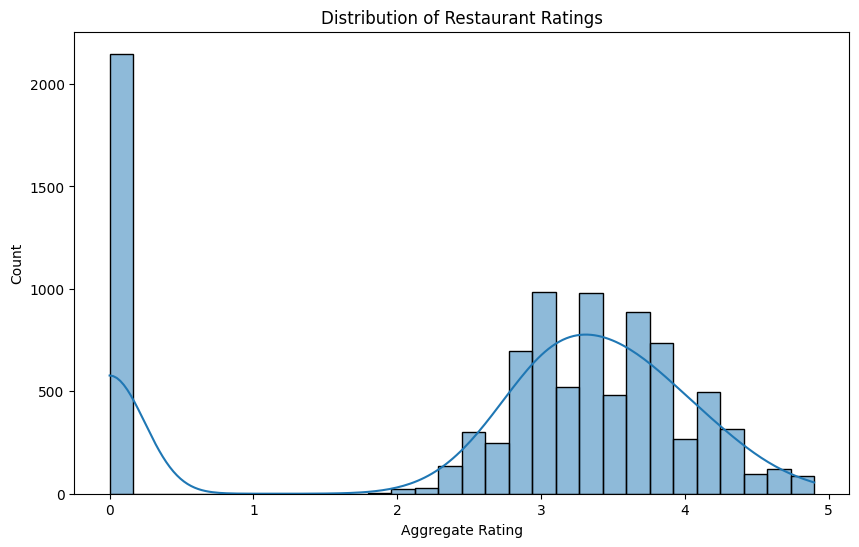

In [10]:
# Distribution of Aggregate Rating

plt.figure(figsize=(10,6))

sns.histplot(df['Aggregate rating'], bins=30, kde=True)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Count")

plt.show()

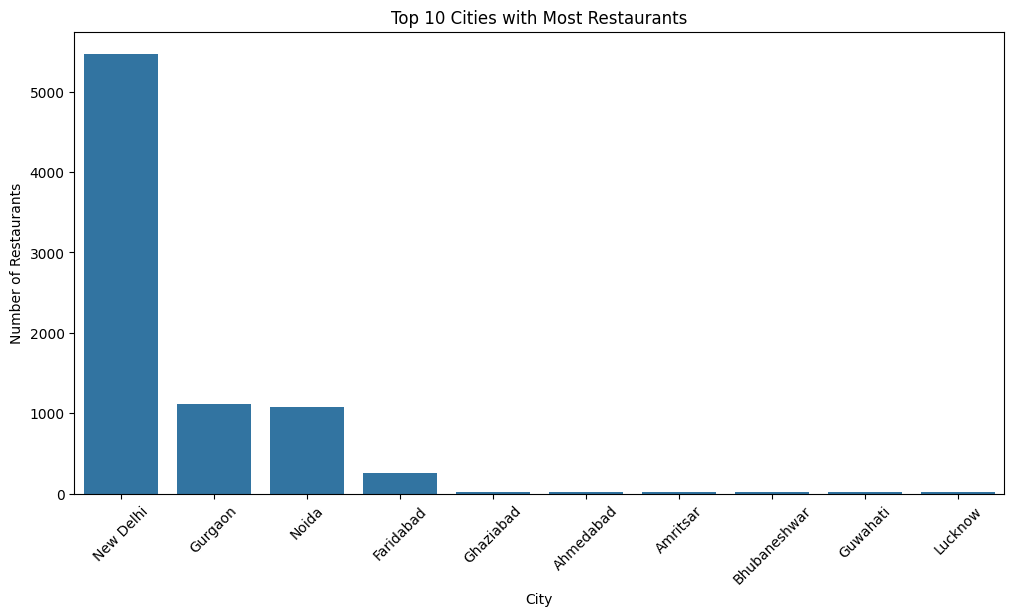

In [11]:
# Top cities by restaurant count

top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_cities.index, y=top_cities.values)

plt.title("Top 10 Cities with Most Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

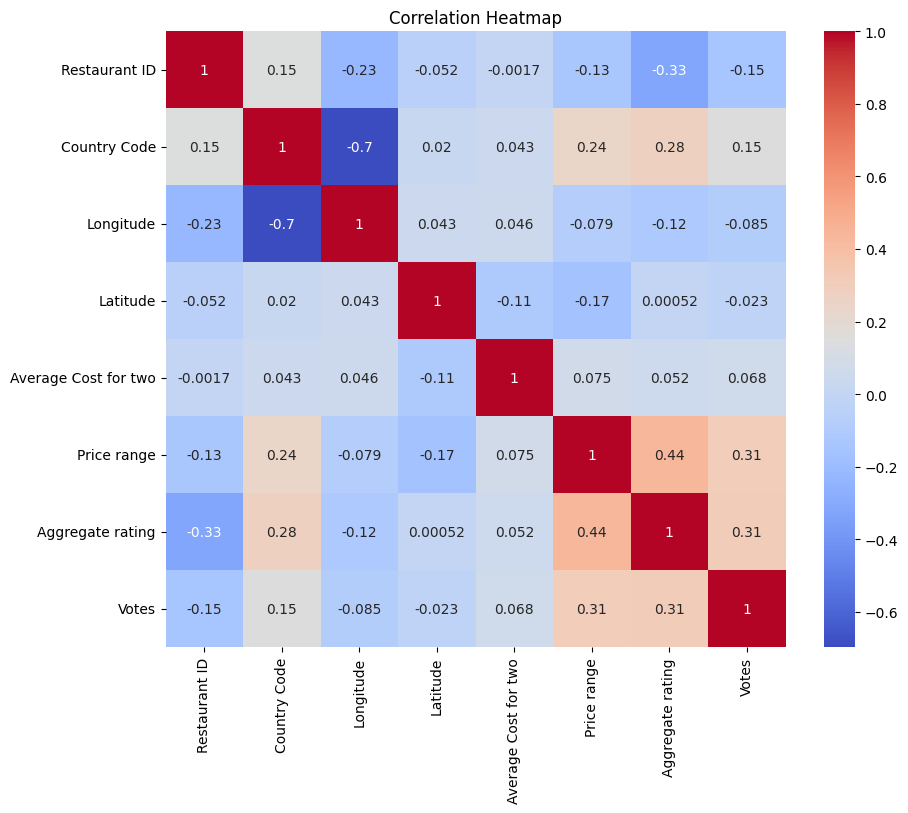

In [12]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [13]:
# Selecting important features

features = [
    'Country Code',
    'Longitude',
    'Latitude',
    'Average Cost for two',
    'Price range',
    'Votes'
]

X = df[features]

# Target variable
y = df['Aggregate rating']

print(X.head())
print(y.head())

   Country Code   Longitude   Latitude  Average Cost for two  Price range  \
0           162  121.027535  14.565443                  1100            3   
1           162  121.014101  14.553708                  1200            3   
2           162  121.056831  14.581404                  4000            4   
3           162  121.056475  14.585318                  1500            4   
4           162  121.057508  14.584450                  1500            4   

   Votes  
0    314  
1    591  
2    270  
3    365  
4    229  
0    4.8
1    4.5
2    4.4
3    4.9
4    4.8
Name: Aggregate rating, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (7640, 6)
Testing Data: (1911, 6)


In [15]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [16]:
# Predictions

y_pred = lr_model.predict(X_test)

print(y_pred[:10])

[2.08616337 2.6787926  2.64962859 2.15671221 2.06124452 2.05208129
 2.06882116 2.05022829 2.08165829 2.64209548]


In [17]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 1.0883323347245504
Mean Squared Error: 1.7013159616834816
Root Mean Squared Error: 1.3043450316858196
R2 Score: 0.25253317441000356


In [18]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [19]:
# Predictions using Random Forest

rf_predictions = rf_model.predict(X_test)

print(rf_predictions[:10])

[3.433 3.172 3.038 3.97  3.049 0.    3.108 0.    3.511 3.336]


In [20]:
# Random Forest Evaluation

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("----------------------")

print("Mean Absolute Error:", rf_mae)
print("Mean Squared Error:", rf_mse)
print("Root Mean Squared Error:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
----------------------
Mean Absolute Error: 0.204371829757544
Mean Squared Error: 0.09687833594395022
Root Mean Squared Error: 0.31125284889290605
R2 Score: 0.9574368642466556


In [21]:
# Feature Importance

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                Feature  Importance
5                 Votes    0.950087
1             Longitude    0.019960
2              Latitude    0.017095
3  Average Cost for two    0.008216
0          Country Code    0.003540
4           Price range    0.001103


# Conclusion

This project successfully developed a machine learning model to predict restaurant ratings using various restaurant-related features.

## Key Achievements
- Performed data preprocessing and handled missing values.
- Conducted exploratory data analysis using professional visualizations.
- Built and evaluated Linear Regression and Random Forest Regression models.
- Achieved excellent performance using Random Forest Regressor with an R² score of 0.95.

## Important Insights
- Votes were found to be the most influential feature affecting restaurant ratings.
- Restaurants with higher customer engagement generally received better ratings.
- Price range and location-related features also contributed to prediction performance.

## Final Outcome
The Random Forest model demonstrated strong predictive capability and can be effectively used for restaurant rating prediction tasks in real-world business applications.

# Restaurant Rating Prediction System

## Cognifyz Technologies Machine Learning Internship

### Objective
To build a machine learning model capable of predicting restaurant aggregate ratings using restaurant-related features.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Machine Learning Algorithms
- Linear Regression
- Random Forest Regressor

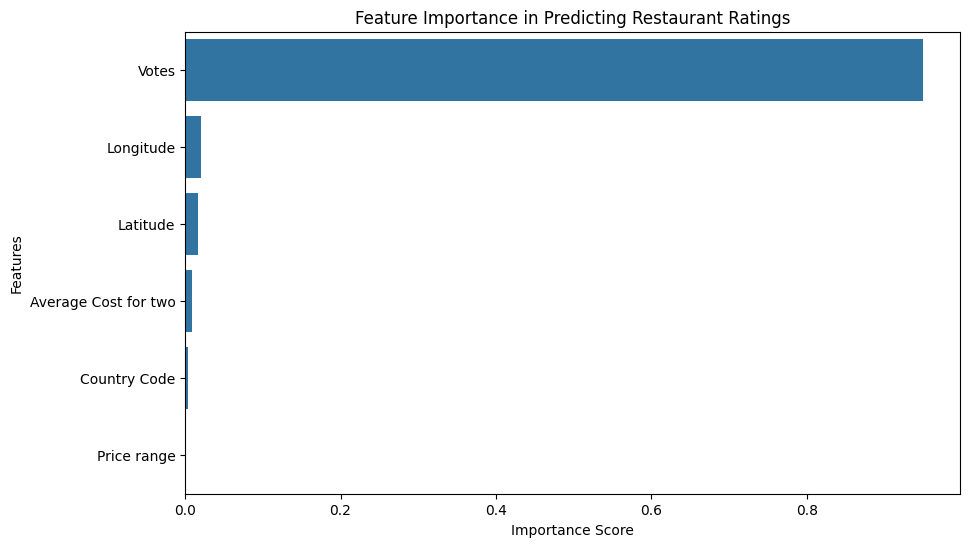

In [24]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance in Predicting Restaurant Ratings")

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

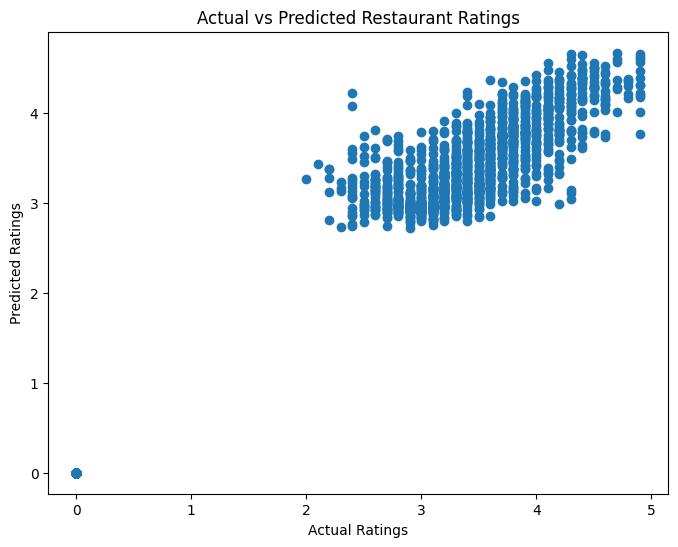

In [25]:
# Actual vs Predicted Ratings

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Restaurant Ratings")

plt.show()